In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/cleaned/customer_health_dataset.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Churn,TenureScore,MonthlyScore,TotalScore,ContractScore,CustomerScore,Segment,HealthScore,RiskLevel,Recommendation
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,0.013889,0.115423,0.003437,0,3.001495,Lost,2.233936,High Risk,Offer retention discount
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,0.472222,0.385075,0.217564,50,35.292942,At Risk,40.381887,Medium Risk,Send engagement campaign
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,0.027778,0.354229,0.012453,0,8.693800,Lost,6.458086,High Risk,Offer retention discount
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,0.625000,0.239303,0.211951,50,38.264100,At Risk,42.638321,Medium Risk,Send engagement campaign
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,0.027778,0.521891,0.017462,0,12.247384,Lost,9.098230,High Risk,Offer retention discount


In [19]:
total_customers = len(df)

print(total_customers)

7043


In [20]:
churn_rate = (
    (df["Churn"] == "Yes")
    .mean()
    * 100
)

print(round(churn_rate,2))

26.54


In [21]:
avg_health_score = (
    df["HealthScore"]
    .mean()
)

print(round(avg_health_score,2))

37.35


In [22]:
high_risk_customers = (
    df["RiskLevel"]
    .eq("High Risk")
    .sum()
)

print(high_risk_customers)

4103


In [23]:
revenue_at_risk = (
    df.loc[
        df["RiskLevel"] == "High Risk",
        "TotalCharges"
    ]
    .sum()
)

print(round(revenue_at_risk,2))

3704947.85


In [24]:
summary = pd.DataFrame({
    "Metric":[
        "Total Customers",
        "Churn Rate (%)",
        "Average Health Score",
        "High Risk Customers",
        "Revenue At Risk"
    ],
    "Value":[
        total_customers,
        round(churn_rate,2),
        round(avg_health_score,2),
        high_risk_customers,
        round(revenue_at_risk,2)
    ]
})

summary

,Metric,Value
0,Total Customers,7043.00
1,Churn Rate (%),26.54
2,Average Health Score,37.35
3,High Risk Customers,4103.00
4,Revenue At Risk,3704947.85


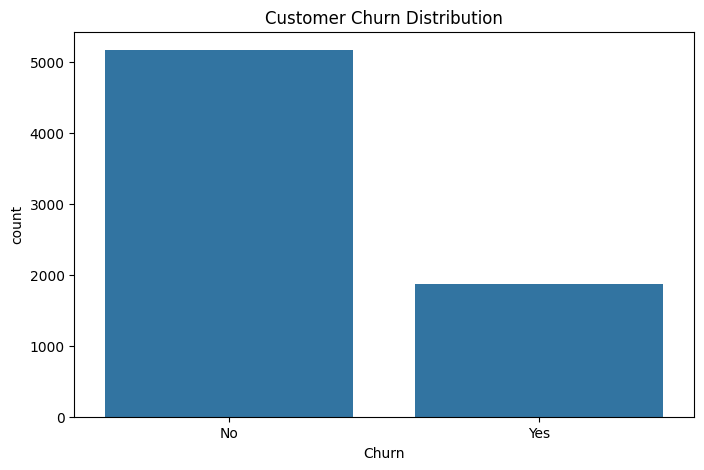

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

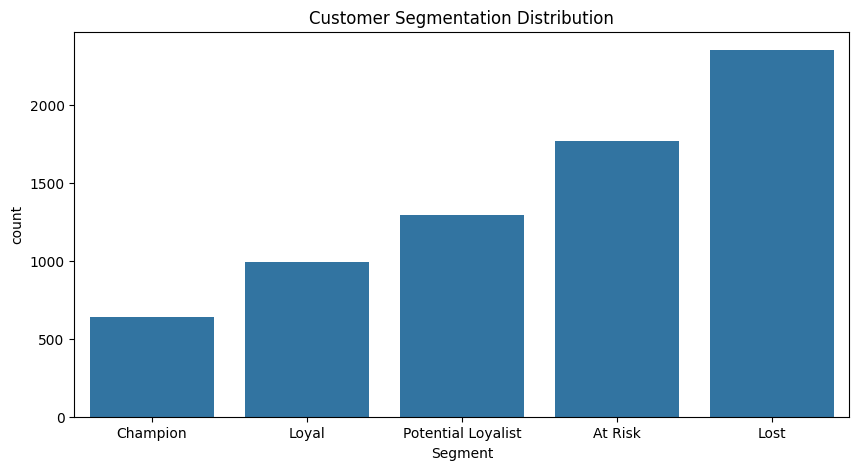

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Segment",
    order=[
        "Champion",
        "Loyal",
        "Potential Loyalist",
        "At Risk",
        "Lost"
    ]
)

plt.title("Customer Segmentation Distribution")
plt.show()

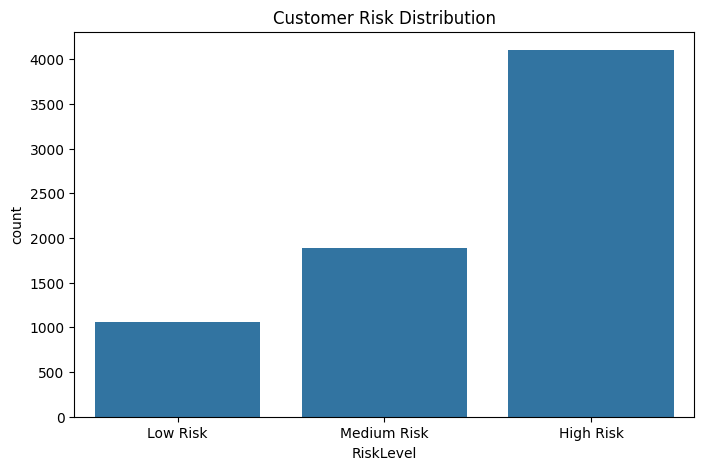

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="RiskLevel",
    data=df,
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Customer Risk Distribution")

plt.show()

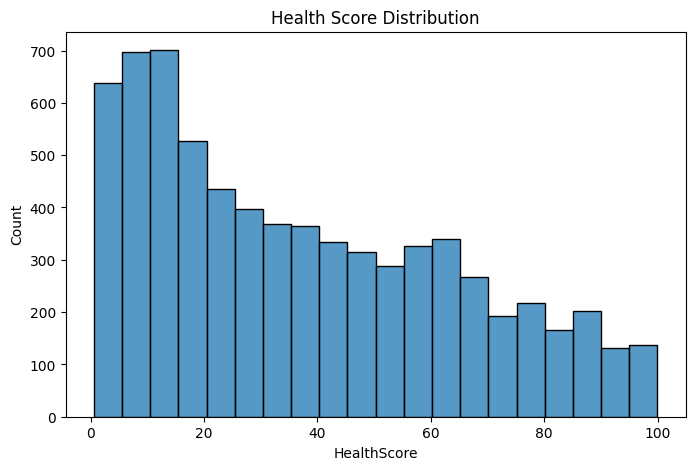

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["HealthScore"],
    bins=20
)

plt.title(
    "Health Score Distribution"
)

plt.show()

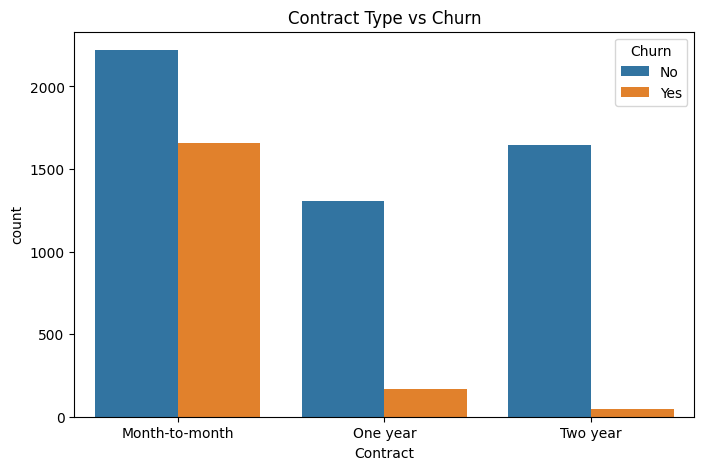

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title(
    "Contract Type vs Churn"
)

plt.show()

In [28]:
total_customers = len(df)

churn_rate = (
    (df["Churn"] == "Yes").mean() * 100
)

avg_health_score = (
    df["HealthScore"].mean()
)

high_risk_customers = (
    df["RiskLevel"].eq("High Risk").sum()
)

revenue_at_risk = (
    df.loc[
        df["RiskLevel"] == "High Risk",
        "TotalCharges"
    ].sum()
)

print("Total Customers:", total_customers)
print("Churn Rate:", round(churn_rate,2))
print("Average Health Score:", round(avg_health_score,2))
print("High Risk Customers:", high_risk_customers)
print("Revenue At Risk:", round(revenue_at_risk,2))

Total Customers: 7043
Churn Rate: 26.54
Average Health Score: 37.35
High Risk Customers: 4103
Revenue At Risk: 3704947.85


# Executive Summary

The Customer Churn Intelligence Platform analyzed 7,043 customers to identify retention risks and business opportunities.

## Key Performance Indicators

- Total Customers: 7,043
- Churn Rate: 26.54%
- Average Health Score: 37.35
- High Risk Customers: 4,103
- Revenue At Risk: $3.70 Million

## Key Findings

1. More than half of customers are classified as High Risk.
2. Month-to-month contracts exhibit the highest churn behavior.
3. Low-tenure customers are significantly more likely to leave.
4. Fiber optic customers show elevated churn rates.
5. High-risk customers represent substantial revenue exposure.

## Business Recommendations

1. Launch targeted retention campaigns for High Risk customers.
2. Incentivize migration to annual and multi-year contracts.
3. Strengthen onboarding programs for new customers.
4. Investigate pricing and satisfaction issues among fiber optic subscribers.
5. Reward Champion and Loyal customers through loyalty programs.